In [1]:
import warnings
warnings.filterwarnings('ignore')

from IPython.core.display import display, HTML
display(HTML('<style>.container {width: 90% !important; }</style>'))

In [2]:
import glob
import pandas as pd

In [22]:
collection = "test/cad"

In [23]:
results = sorted(glob.glob("%s/statistics_intermediate_round*"%collection))
esvar = sorted(glob.glob("%s/statistics_ESVAR.csv"%collection))

In [34]:
dfs = []
for r in results:
    df = pd.read_csv(r, sep='\t', index_col=0)
    df = df[['ESVAR']]
    name = r.split("/")[-1].replace(".csv", "")
    df.index = df.index + "_%s"%name
    dfs.append(df)
    
df = pd.concat(dfs)

print('min value:    ', df['ESVAR'].min())
print('mean value:   ', df['ESVAR'].mean())
print('median value: ', df['ESVAR'].median())
print('max value:    ', df['ESVAR'].max())

min value:     0.310629039413398
mean value:    0.7612756905876932
median value:  0.6459643916824074
max value:     3.081880828568091


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

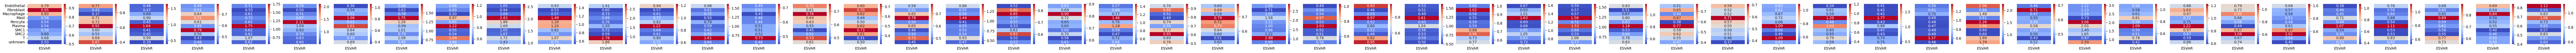

In [36]:
f, ax = plt.subplots(1,len(dfs),figsize=(len(dfs)*2.5,dfs[0].shape[0]/5))
for i, df in enumerate(dfs):
    if i == 0:
        df.index = df.index.str.replace("_statistics_intermediate_round1", "")
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], fmt='.2f', cmap='coolwarm')
    else:
        ax[i] = sns.heatmap(df, annot=True, ax=ax[i], yticklabels=False, fmt='.2f', cmap='coolwarm')
plt.show()

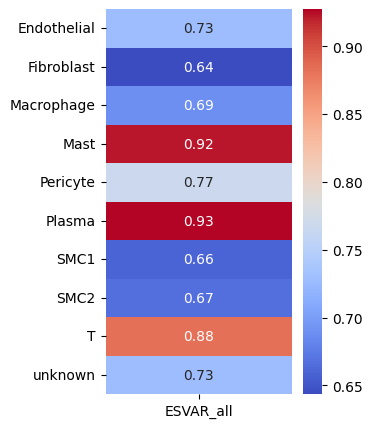

In [33]:
df = pd.read_csv(esvar[0], sep='\t', index_col=0)
f, ax = plt.subplots(1,1,figsize=(3,5))
ax = sns.heatmap(df, annot=True, ax=ax, fmt='.2f', cmap='coolwarm')
plt.show()